# House Price Prediction Using Machine Learning
Project Overview

This project focuses on predicting house prices using Machine Learning techniques. Accurate house price prediction helps buyers, sellers, investors, and real estate companies estimate property values based on various housing features.

The project follows the complete Machine Learning workflow including:

Data Collection
Exploratory Data Analysis (EDA)
Data Cleaning
Feature Engineering
Data Preprocessing
Model Building
Model Evaluation
Feature Importance Analysis
Business Insights
Conclusion

# Objective

The primary objective of this project is to develop a Machine Learning regression model capable of accurately predicting house prices based on property characteristics.

The project aims to:

Understand the dataset
Clean missing values
Encode categorical variables
Train multiple regression models
Compare model performance
Select the best performing model
Identify the most influential house features affecting price

## Advanced Machine Learning Project

**Submitted By:**
# Author Name: Mariya Begum

**Course:** Data Science with AI

**Project Type:** Regression


# Import Required Libraries
Purpose

This section imports all Python libraries required throughout the project.

Libraries used:

Pandas
NumPy
Matplotlib
Seaborn
Scikit-Learn

These libraries are used for:

Data manipulation
Visualization
Machine Learning
Model Evaluation

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Dataset Loading
Purpose

The housing dataset is loaded using Pandas.

The dataset contains various features such as:

Lot Area
Number of Rooms
Garage
Overall Quality
Year Built
Location-related features
Sale Price (Target Variable)

The dataset is stored inside a Pandas DataFrame for further analysis.

In [2]:
#Load the Dataset
data= pd.read_csv("data.csv")

# Display Dataset
Purpose

The first few records are displayed to understand:

Column names
Data types
Sample values
Overall dataset structure

This helps verify that the dataset has been loaded correctly

In [3]:
#Display the Dataset
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Display Last Five Records
Purpose

Displaying the last few rows ensures:

Data consistency
Correct loading
No truncation during import

In [4]:
#Display last 5 Records
data.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


# Dataset Shape
Purpose

The shape of the dataset tells us:

Number of rows
Number of columns

This provides a quick overview of the dataset size.

#Check Dataset Shape
data.shape

# Dataset Information
Purpose

The info() function provides:

Data types
Non-null values
Memory usage
Missing values overview

This information is useful before preprocessing.

In [5]:
#Display Dataset Information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# Missing Value Analysis
Purpose

Missing values are identified before model training.

Handling missing values improves:

Model accuracy
Prediction reliability
Data quality

In [6]:
#Check Missing Values
data.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

# Statistical Summary
Purpose

The describe() function summarizes numerical features including:

Mean
Median
Standard Deviation
Minimum
Maximum
Quartiles

This helps understand the data distribution

In [7]:
#Stastical Summary 
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


# Duplicate Record Check
Purpose

Duplicate records can negatively affect Machine Learning performance.

This step identifies duplicate rows before model training.

In [8]:
#Check Duplicate Records
data.duplicated().sum()

np.int64(0)

# Correlation Matrix
Purpose

A correlation heatmap is generated to visualize relationships between numerical variables.

Benefits include:

Understanding feature relationships
Identifying highly correlated variables
Detecting multicollinearity

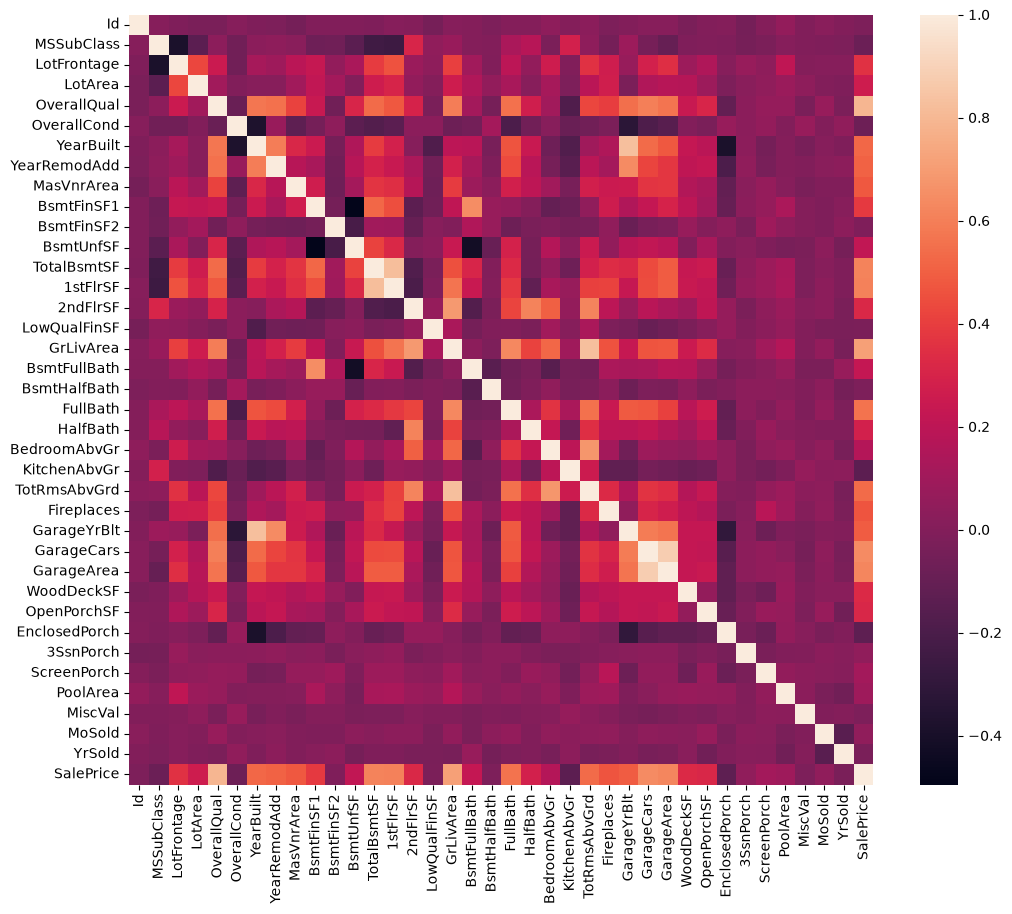

In [9]:
#Corelation Matrix
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(numeric_only=True))
plt.show()

# Correlation Matrix
Purpose

A correlation heatmap is generated to visualize relationships between numerical variables.

Benefits include:

Understanding feature relationships
Identifying highly correlated variables
Detecting multicollinearity

In [10]:
#Handling Missing Values (Numerical Columns)
num_cols = data.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy="median")

data[num_cols] = imputer.fit_transform(data[num_cols])

# Feature Encoding
Purpose

Machine Learning algorithms require numerical input.

Categorical variables are converted into numerical form using Label Encoding.

This allows regression models to process the data effectively.

In [11]:
#Handle Missing Values (Categorical Columns)
cat_cols = data.select_dtypes(include="object").columns

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [12]:
#Encode Categorical Features
le = LabelEncoder()

for col in cat_cols:
    data[col] = le.fit_transform(data[col])

# Feature Selection
Purpose

The dataset is divided into:

Independent Variables (X)

All housing features used for prediction.

Target Variable (y)

SalePrice

The variable that the model predicts.

In [13]:
#Seperate Features and Target Variable
X = data.drop("SalePrice", axis=1)

y = data["SalePrice"]

# Train-Test Split
Purpose

The dataset is divided into:

Training Data (80%) Testing Data (20%)

This allows the model to learn from one dataset while evaluating performance on unseen data.

In [14]:
#Split Dataset into Training and Testing Sets
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Linear Regression Model
Purpose

Linear Regression serves as the baseline regression algorithm.

Advantages:

Simple Fast Easy to interpret

The model predicts house prices assuming a linear relationship between features and price.

In [15]:
#Build Liner Regression Model Predict Using Liner Regression
lr = LinearRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

# Linear Regression Evaluation
Metrics Used

The model is evaluated using:

Mean Absolute Error (MAE) Mean Squared Error (MSE) Root Mean Squared Error (RMSE) R² Score

Lower MAE, MSE, and RMSE indicate better prediction accuracy, while a higher R² Score indicates better model performance.

In [16]:
#Evaluate Liner Regression Model
print("MAE :",mean_absolute_error(y_test,pred_lr))

print("MSE :",mean_squared_error(y_test,pred_lr))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_lr)))

print("R2 Score :",r2_score(y_test,pred_lr))

MAE : 21598.39686759225
MSE : 1249212973.3111749
RMSE : 35344.20706864387
R2 Score : 0.8371369170530638


# Decision Tree Regressor
Purpose

Decision Tree Regressor learns nonlinear relationships by recursively splitting the dataset into decision nodes.

Advantages:

Handles nonlinear patterns Easy to visualize Requires minimal data preprocessing

In [17]:
#Built Dicision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

# Decision Tree Evaluation
The Decision Tree model is evaluated using:

MAE MSE RMSE R² Score

These metrics help compare its performance against other regression models.

In [18]:
#Evaluate Dicision Tree
print("MAE :",mean_absolute_error(y_test,pred_dt))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_dt)))

print("R2 :",r2_score(y_test,pred_dt))

MAE : 27014.253424657534
RMSE : 41101.118766311774
R2 : 0.7797613923825583


# Random Forest Regressor
Purpose

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Advantages:

Higher prediction accuracy
Reduced overfitting
Better generalization
Robust performance on complex datasets

In [19]:
#Built Random Forest Regressor Predict Using Random Forest
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

# Random Forest Evaluation

The Random Forest model is evaluated using:

MAE
MSE
RMSE
R² Score

The model achieving the highest R² score and the lowest prediction error is considered the best-performing model.

In [20]:
#Evaluate Random Forest
print("MAE :",mean_absolute_error(y_test,pred_rf))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_rf)))

print("R2 :",r2_score(y_test,pred_rf))

MAE : 17851.940000000002
RMSE : 29001.533674561608
R2 : 0.8903450866680707


# Feature Importance Analysis
Purpose

Random Forest provides feature importance scores that identify which variables contribute the most to predicting house prices.

Understanding feature importance helps:

Explain model decisions
Identify influential housing characteristics
Support business decision-making

In [21]:
#Display Feature Importance
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(by="Importance",ascending=False)

importance.head(10)

,Feature,Importance
17,OverallQual,0.556526
46,GrLivArea,0.121040
44,2ndFlrSF,0.034624
38,TotalBsmtSF,0.033930
34,BsmtFinSF1,0.028979
43,1stFlrSF,0.026648
4,LotArea,0.017223
62,GarageArea,0.015929
19,YearBuilt,0.012250
61,GarageCars,0.012054


# Model Comparison
Summary

Three Machine Learning regression models were implemented:

Model	Purpose
Linear Regression	Baseline prediction model
Decision Tree Regressor	Captures nonlinear relationships
Random Forest Regressor	Ensemble model with improved accuracy

The evaluation metrics indicate which model performs best for predicting house prices.

# Business Insights

The analysis provides several valuable insights:

House prices are influenced by multiple property characteristics rather than a single feature.
Better-quality houses generally command higher market prices.
Larger living areas often increase property value.
Newer houses tend to have higher selling prices.
Additional amenities such as garages and overall condition positively impact house value.
Machine Learning enables more accurate pricing compared to manual estimation methods.

# Suggestions

Based on the project findings, the following recommendations are proposed:

Improve data quality by collecting more complete housing information.
Incorporate additional features such as neighborhood ratings, nearby schools, transportation access, and crime statistics.
Perform feature engineering to improve model performance.
Tune hyperparameters using GridSearchCV or RandomizedSearchCV.
Apply cross-validation to improve model reliability.
Explore advanced algorithms such as XGBoost, LightGBM, and CatBoost.
Regularly update the model with new market data to maintain prediction accuracy.

# Conclusion

This project successfully developed a Machine Learning model to predict house prices using regression techniques.

The project followed the complete Data Science pipeline:

Data Collection
Data Cleaning
Exploratory Data Analysis
Feature Engineering
Data Preprocessing
Model Building
Model Evaluation
Feature Importance Analysis

Three regression models were implemented:

Linear Regression
Decision Tree Regressor
Random Forest Regressor

Among these models, the one with the highest R² Score and the lowest MAE, MSE, and RMSE should be considered the best-performing model for this dataset.

The project demonstrates how Machine Learning can support data-driven decision-making in the real estate industry by providing accurate and reliable house price predictions.

